<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 123.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 98.9 MB/s eta 0:00:00


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 139.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 140.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 103.6 MB/s eta 0:00:00


In [3]:
!pip install seaborn

In [31]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 129.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 63.6 MB/s eta 0:00:00a 0:00:01


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [5]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [6]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [7]:
## Write your code here
duplicate_rows_mask = df.duplicated(keep=False)
df_duplicates_all = df[duplicate_rows_mask]
print(f'Number of duplicate rows: {df_duplicates_all.shape[0]}')

Number of duplicate rows: 0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['ResponseId'].duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)
df.shape

(65437, 114)

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [11]:
df.isnull().sum()

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

In [12]:
## Write your code here
print(f"Number of missing values in the 'CodingActivities' column: {df['CodingActivities'].isnull().sum()}")

Number of missing values in the 'CodingActivities' column: 10971


##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [13]:
## Write your code here
vc_ca = df['CodingActivities'].value_counts()
vc_ca.head(4)

CodingActivities
Hobby                                                                        9993
I don’t code outside of work                                                 6508
Hobby;Professional development or self-paced learning from online courses    6203
Hobby;Contribute to open-source projects                                     3732
Name: count, dtype: int64

In [14]:
df['CodingActivities'] = df['CodingActivities'].ffill()

In [15]:
vc_ca = df['CodingActivities'].value_counts()
vc_ca.head(4)

CodingActivities
Hobby                                                                        11972
I don’t code outside of work                                                  7762
Hobby;Professional development or self-paced learning from online courses     7405
Hobby;Contribute to open-source projects                                      4469
Name: count, dtype: int64

In [16]:
print(f"Number of missing values in the 'CodingActivities' column: {df['CodingActivities'].isnull().sum()}")

Number of missing values in the 'CodingActivities' column: 0


**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [17]:
## Write your code here #ConvertedCompYearly #CompTotal
#print(list(df.columns))

In [18]:
name_cols = df.columns[df.columns.str.contains('Comp')]
print(name_cols)

Index(['CompTotal', 'AIComplex', 'ConvertedCompYearly'], dtype='object')


In [19]:
#df[['CompTotal', 'AIComplex', 'ConvertedCompYearly']].info()

In [20]:
#df[['CompTotal', 'ConvertedCompYearly']].describe()

In [21]:
df['ConvertedCompYearly'].isnull().sum()

np.int64(42002)

In [22]:
mean_ccompyr = df['ConvertedCompYearly'].mean()

In [23]:
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(mean_ccompyr)

In [24]:
df['ConvertedCompYearly'].isnull().sum()

np.int64(0)

In [25]:
df['CompTotal'].isnull().sum()

np.int64(31697)

In [26]:
mean_compt = df['CompTotal'].mean()

In [27]:
df['CompTotal'] = df['CompTotal'].fillna(mean_compt)

In [28]:
df['CompTotal'].isnull().sum()

np.int64(0)

In [60]:
df['YearsCode'].isnull().sum()

np.int64(5568)

In [68]:
mean_yrcode = df['YearsCode'].mode()[0]
print(mean_yrcode)

10


In [69]:
df['YearsCode'] = df['YearsCode'].fillna(mean_yrcode)

In [70]:
df['CompTotal'].isnull().sum()

np.int64(0)

##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [32]:
## Write your code here
from sklearn.preprocessing import MinMaxScaler

In [33]:
scaler = MinMaxScaler()
df['ConvertedCompYearly_MinMax'] = scaler.fit_transform(df[['ConvertedCompYearly']])

In [34]:
df['ConvertedCompYearly_MinMax'].describe()

count    65437.000000
mean         0.005300
std          0.006875
min          0.000000
25%          0.005300
50%          0.005300
75%          0.005300
max          1.000000
Name: ConvertedCompYearly_MinMax, dtype: float64

##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [35]:
## Write your code here
from scipy.stats import zscore

In [36]:
df['ConvertedCompYearly_Zscore'] = zscore(df['ConvertedCompYearly'])

In [37]:
df['ConvertedCompYearly_Zscore'].describe()

count    6.543700e+04
mean     1.020692e-17
std      1.000008e+00
min     -7.708831e-01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.446884e+02
Name: ConvertedCompYearly_Zscore, dtype: float64

In [165]:
#df['ConvertedCompYearly_Normalized'] = (df['ConvertedCompYearly'] - df['ConvertedCompYearly'].min()) / (df['ConvertedCompYearly'].max() - df['ConvertedCompYearly'].min())

In [166]:
#df['ConvertedCompYearly_Normalized'].describe()

In [167]:
#import numpy as np
#df['Log_ConvertedCompYearly'] = np.log1p(df['ConvertedCompYearly'])

In [168]:
#df['Log_ConvertedCompYearly'].describe()

In [169]:
# Calculate mean and standard deviation
#mean = df['ConvertedCompYearly'].mean()
#std = df['ConvertedCompYearly'].std()

# Apply the Z-score formula: (x - mean) / std
#df['ConvertedCompYearly_Z'] = (df['ConvertedCompYearly'] - mean) / std

In [170]:
#df['ConvertedCompYearly_Z'].describe()

### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


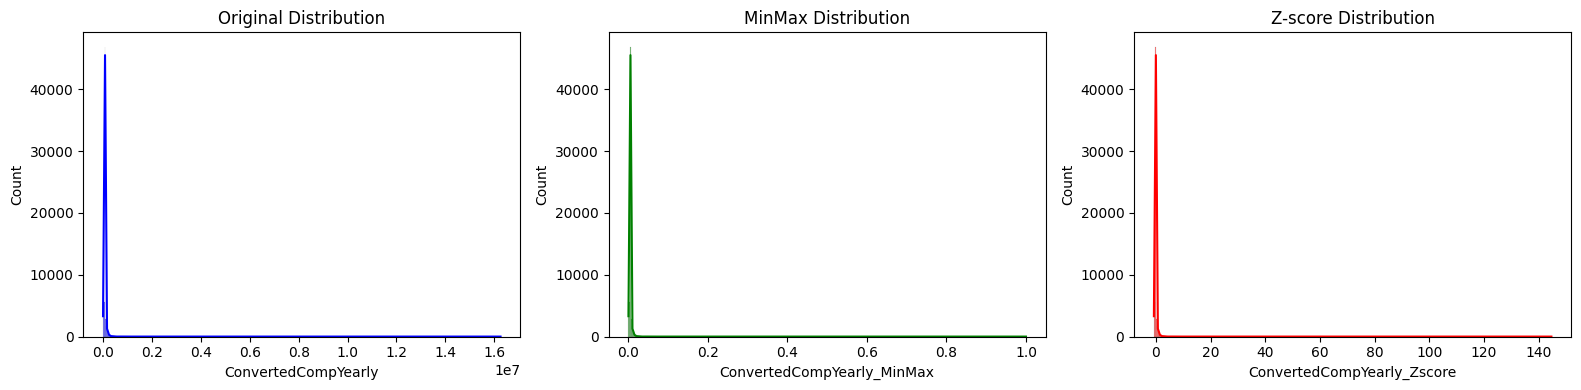

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4)) # Create a figure with 3 subplots
sns.histplot(df['ConvertedCompYearly'], kde=True, ax=axes[0], color='blue') # Plot 1: Raw Salary
axes[0].set_title('Original Distribution')
sns.histplot(df['ConvertedCompYearly_MinMax'], kde=True, ax=axes[1], color='green') # Plot 2: Normalized Salary
axes[1].set_title('MinMax Distribution')
sns.histplot(df['ConvertedCompYearly_Zscore'], kde=True, ax=axes[2], color='red') # Plot 3: Z-score Scaled Salary
axes[2].set_title('Z-score Distribution')
plt.tight_layout() # Display Plot
plt.show()

In [79]:
new_df = df[['ConvertedCompYearly', 'ConvertedCompYearly_MinMax', 'ConvertedCompYearly_Zscore']].copy()
#new_df.head()

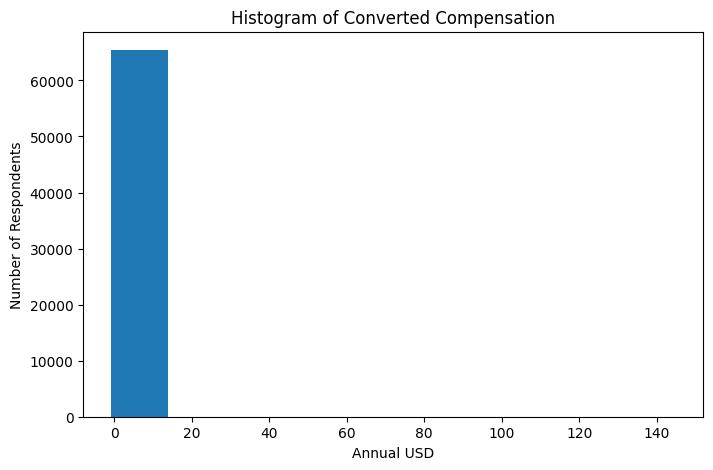

In [82]:
# plot histogram
new_df['ConvertedCompYearly_Zscore'].plot(kind='hist', figsize=(8, 5))
# add a title to the histogram
plt.title('Histogram of Converted Compensation')
# add y-label
plt.ylabel('Number of Respondents')
# add x-label
plt.xlabel('Annual USD')

plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

# Assuming new_df is your DataFrame with 'ConvertedCompYearly_Zscore' column
# Example of creating a new column 'is_outlier' based on Z-score
new_df['is_outlier'] = (new_df['ConvertedCompYearly_Zscore'].abs() > 3)

plt.figure(figsize=(10, 6)) # Set the figure size for better readability
# Create the histogram with KDE, coloring by the 'is_outlier' boolean
sns.histplot(data=new_df, x='ConvertedCompYearly_Zscore', kde=True, hue='is_outlier', color='red')
plt.title('Z-score Distribution of Yearly Salary (Outliers Highlighted)') # Added more context to title
plt.xlabel('Z-score (Years of Experience)') # Added x-axis label
plt.ylabel('Frequency') # Added y-axis label
plt.tight_layout() # Adjusts plot to prevent labels from overlapping
plt.show() # Display the plot

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
# 1. Create dummy data
df = pd.DataFrame({'values': np.random.normal(loc=50, scale=10, size=1000)})

# 2. Calculate Z-scores
# Formula: (x - mean) / std
df['zscore'] = zscore(df['values'])
df['zscore'].describe()

# 3. Plot Histogram of Z-scores
plt.figure(figsize=(10, 6))
sns.histplot(df['zscore'], kde=True, color='skyblue')
plt.title('Histogram of Z-score Distribution (2026)')
plt.xlabel('Z-score (Standard Deviations from Mean)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Mean (0)')
plt.legend()
plt.show()

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
